In [1]:
from transformers import PreTrainedTokenizerFast
import json
import os
from glob import glob
import matplotlib.pyplot as plt
import numpy as np
from collections import defaultdict, Counter
import ipywidgets as widgets
from IPython.display import display, HTML
import matplotlib.pyplot as plt
import numpy as np
from ipywidgets import interact
from tqdm import tqdm
base_path = "../data/eval_results/Pythia-24-8-256-dfs"
# base_path = "../data/eval_results/PAST-6-4-128-dfs"
val_data = "../data/sos_filtered/val1_b4_t30_n500000_dfs_filtered.json"

/scratch/project/open-30-4/Petr_Hyner/ENVS/rl_sos/lib/python3.11/site-packages/transformers/utils/hub.py:128: FutureWarning: Using `TRANSFORMERS_CACHE` is deprecated and will be removed in v5 of Transformers. Use `HF_HOME` instead.
  warnings.warn(


In [2]:
def load_step_jsons(base_path):
    """
    Load JSON-formatted files from step folders, checking first for files without 
    extensions, then falling back to .json files if none found.
    
    Args:
        base_path (str): Path to the directory containing step folders
        
    Returns:
        list: List of tuples containing (step_number, json_data)
    """
    results = []
    
    # Get all step directories using glob
    step_dirs = glob(os.path.join(base_path, "step_*"))
    for step_dir in step_dirs:
        try:
            # Extract step number from directory name
            step_num = int(os.path.basename(step_dir).split('_')[1])
            
            # List all files in the directory
            files = os.listdir(step_dir)
            
            # First look for files without extensions
            json_files = [os.path.join(step_dir, f) for f in files if os.path.isfile(os.path.join(step_dir, f)) and '.' not in f]
            
            # If no extensionless files found, look for .json files
            if not json_files:
                json_files = glob(os.path.join(step_dir, "*.json"))
            
            if json_files:
                json_path = json_files[0]  # Now json_files already contains full paths
                
                # Read and parse JSON
                with open(json_path, 'r') as f:
                    data = json.load(f)
                    
                results.append((step_num, data))
        except ValueError as e:
            print(f"Error parsing step number from {step_dir}: {e}")
        except json.JSONDecodeError as e:
            print(f"Error parsing JSON in step {step_num}: {e}")
        except Exception as e:
            print(f"Error processing {step_dir}: {e}")
    
    # Sort results by step number
    results.sort(key=lambda x: x[0])
    
    return results

jsons = load_step_jsons(base_path)

print(f"Loaded {len(jsons)} JSON files")

eval_data = []
with open(val_data, "r") as f:
    for line in f:
        if line.strip():
            try:
                eval_data.append(json.loads(line))
            except json.JSONDecodeError as e:
                print(f"Error parsing line: {e}")
                continue

def get_tokenizer(path):
    tokenizer = PreTrainedTokenizerFast(
        tokenizer_file=path
    )
    tokenizer.eos_token = "[EOS]"
    tokenizer.unk_token = "[UNK]"
    tokenizer.pad_token = "[PAD]"
    tokenizer.mask_token = "[MASK]"
    tokenizer.bos_token = "[BOS]"
    tokenizer.pad_token = tokenizer.eos_token
    return tokenizer


Loaded 39 JSON files


In [3]:
eval_data[0]

{'nums': [23, 19, 15, 13],
 'target': 15,
 'solution': ['23+15=38', '38/19=2', '13+2=15'],
 'search_path': 'S 15 [ 23 19 15 13 ] , E 23 - 13 = 10 R [ 23 19 15 13 ] , G #00 15 [ 23 19 15 13 ] , M #00 , S 15 [ 19 15 10 ] , E 19 - 10 = 9 R [ 19 15 10 ] , G #000 15 [ 19 15 10 ] , M #000 , S 15 [ 15 9 ] , E 15 + 9 = 24 R [ 15 9 ] , N 24 15 ; M #000 , S 15 [ 15 9 ] , E 15 - 9 = 6 R [ 15 9 ] , N 6 15 ; M #00 , S 15 [ 19 15 10 ] , E 19 + 10 = 29 R [ 19 15 10 ] , G #001 15 [ 19 15 10 ] , M #001 , S 15 [ 15 29 ] , E 29 - 15 = 14 R [ 15 29 ] , N 14 15 ; M #00 , S 15 [ 19 15 10 ] , E 15 + 10 = 25 R [ 19 15 10 ] , G #002 15 [ 19 15 10 ] , M #002 , S 15 [ 19 25 ] , E 25 - 19 = 6 R [ 19 25 ] , N 6 15 ; M #00 , S 15 [ 19 15 10 ] , E 15 - 10 = 5 R [ 19 15 10 ] , G #003 15 [ 19 15 10 ] , M #003 , S 15 [ 19 5 ] , E 19 - 5 = 14 R [ 19 5 ] , N 14 15 ; M #003 , S 15 [ 19 5 ] , E 19 + 5 = 24 R [ 19 5 ] , N 24 15 ; M #00 , S 15 [ 19 15 10 ] , E 19 - 15 = 4 R [ 19 15 10 ] , G #004 15 [ 19 15 10 ] , M #004 , S 

In [ ]:
tokenizer = get_tokenizer("../tokenizer/tokenizer.json")

def compare_lists(list1, list2):
    # Get the length of the longer list
    max_length = max(len(list1), len(list2))
    
    # Initialize result list with zeros
    result = [0] * max_length
    
    # Compare elements at corresponding indices
    for i in range(min(len(list1), len(list2))):
        if list1[i] == list2[i]:
            result[i] = 1
            
    return result

def get_eval_ids_lst(eval_data, num_samples):
    ret = []
    for i, sample in enumerate(eval_data):
        if i < num_samples:
            sp = sample["search_path"][10:]
            encoded_2 = tokenizer.encode(sp, return_tensors='pt')
            ret.append(encoded_2.tolist()[0])
    return ret

eval_input_ids = get_eval_ids_lst(eval_data, 512)
full_dic = defaultdict(list)
for js in tqdm(jsons):
    ix = 0
    step_num = js[0]
    for traj in js[1]["trajectories"]:
        traj = traj.replace("[BOS] ", "")[10:]
        encoded = tokenizer.encode(traj, return_tensors='pt')
        out_ids_lst = encoded.tolist()[0]
        result = compare_lists(out_ids_lst, eval_input_ids[ix])
        count_matches = result.count(1)
        match_indices = [i for i, value in enumerate(result) if value == 1]
        tokenized_out = tokenizer.tokenize(traj)
        match_toks = []
        for index in match_indices:
            match_toks.append(tokenized_out[index])

        full_dic[step_num].append((ix, count_matches, match_indices, match_toks))
        ix+=1



 10%|█         | 4/39 [01:48<18:15, 31.30s/it]

In [13]:
aggr = []
for k, v in full_dic.items():
    all_matches = 0
    for i, res in enumerate(v):
        ix, num_matches, indices, tokens = res
        all_matches += num_matches
    aggr.append(all_matches/i)
print(aggr)

[7.784735812133072, 100.49706457925636, 69.92367906066536, 72.74559686888453, 218.68493150684932, 251.49510763209392, 321.53816046966733, 398.133072407045, 482.4246575342466, 656.7377690802348, 722.0391389432485, 762.0039138943249, 855.6634050880626, 873.8043052837573, 949.1232876712329, 972.3639921722114, 1011.3561643835617, 1020.7436399217221, 993.0450097847358, 1054.1311154598825, 1077.33072407045, 1079.0528375733854, 1089.9256360078277, 1093.293542074364, 1094.3972602739725, 1113.078277886497, 1112.20156555773, 1129.0234833659492, 1114.6594911937377, 1097.1780821917807, 1133.252446183953, 1117.8160469667318, 1120.86301369863, 1124.2837573385518, 1131.3679060665363, 1120.0939334637965, 1110.1663405088063, 1109.2407045009784, 1087.0998043052837, 0.0]


In [14]:
toks = []
for k, v in full_dic.items():
    toks_temp = []
    for i, res in enumerate(v):
        _, _, _, tokens = res
        toks_temp.append(tokens)
    toks.append(toks_temp)

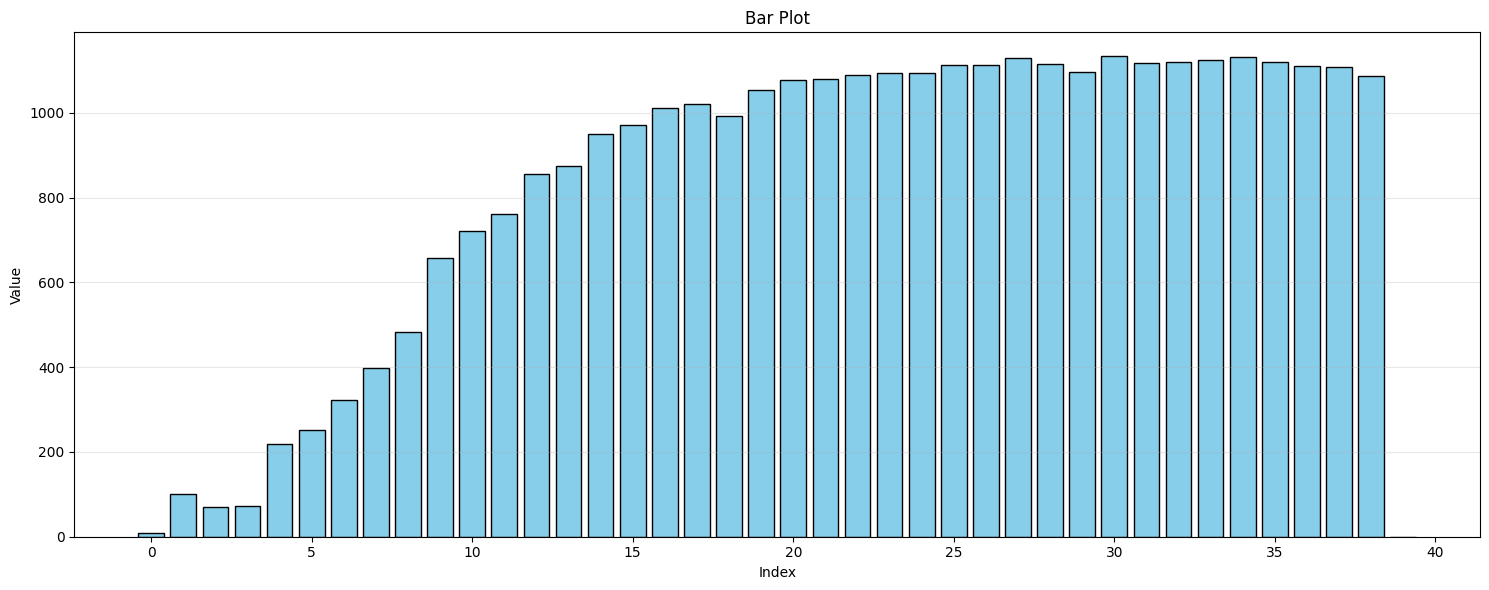

In [15]:
data=aggr
# Create figure and axis
plt.figure(figsize=(15, 6))

# Create bar plot
plt.bar(range(len(data)), data, color='skyblue', edgecolor='black')

# Customize the plot
plt.title('Bar Plot')
plt.xlabel('Index')
plt.ylabel('Value')

# Add grid for better readability
plt.grid(True, alpha=0.3, axis='y')

# Display the plot
plt.tight_layout()
plt.show()

In [16]:
ret = defaultdict(list)
for ix, json in enumerate(toks):
    dic = Counter()  # Use Counter directly instead of regular dict
    for lst in json:
        dic.update(Counter(lst))  # Update will sum the counts
    
    ret[ix].append(dict(dic))

In [17]:
len(ret)

40

In [18]:
ret[4]

[{'19': 1702,
  '15': 1513,
  '13': 1300,
  ']': 12074,
  ',': 21169,
  'E': 4206,
  '23': 603,
  '-': 1522,
  '=': 4212,
  'R': 4199,
  '[': 12553,
  'G': 1716,
  '#00': 1550,
  'M': 4912,
  'S': 4904,
  '#000': 1268,
  '+': 622,
  'N': 2107,
  ';': 2069,
  '#001': 679,
  '2': 529,
  '#015': 8,
  '25': 1108,
  '14': 1363,
  '20': 1384,
  '#002': 387,
  '8': 563,
  '24': 1380,
  '16': 1262,
  '12': 1724,
  '26': 941,
  '#003': 226,
  '#004': 212,
  '1': 493,
  '#005': 152,
  '#010': 44,
  '#01': 107,
  '#011': 37,
  '4': 329,
  '6': 465,
  '7': 526,
  '9': 646,
  '21': 1446,
  '5': 469,
  '18': 1486,
  '28': 926,
  '10': 1407,
  '22': 1703,
  '11': 1535,
  '29': 1145,
  '27': 1058,
  '0': 11,
  '3': 421,
  '*': 48,
  '/': 4,
  '#006': 15,
  '#0': 17,
  '#012': 19,
  '17': 1196,
  '#05': 17,
  '#014': 7,
  '34': 4,
  '#008': 2,
  '#03': 6,
  '#034': 2,
  '35': 1,
  '#030': 2,
  '#013': 8,
  '#02': 4,
  '#020': 1,
  '#050': 1,
  '#04': 4,
  '#051': 2,
  '#06': 2,
  '#060': 1,
  '36': 4,


In [19]:
def plot_histogram(index):
    # Get the dictionary for the specified index
    data = ret[index][0]  # ret[index] is a list containing one dict
    
    # Create the histogram
    plt.figure(figsize=(15, 6))
    plt.bar(range(len(data)), list(data.values()))
    
    # Set the x-axis labels (tokens)
    plt.xticks(range(len(data)), list(data.keys()), rotation=45, ha='right')
    
    plt.title(f'Token Counts for Dictionary {index}')
    plt.xlabel('Tokens')
    plt.ylabel('Count')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


@interact(index=(0, 57))
def plot_interactive_histogram(index):
    plot_histogram(index)

interactive(children=(IntSlider(value=28, description='index', max=57), Output()), _dom_classes=('widget-inter…

In [47]:
def create_highlighted_text(step_num, traj_idx):
    text = eval_data[traj_idx]["search_path"]
    text_lst = text.split(" ")
    
    # Access data exactly like your script
    _, _, match_indices, _ = full_dic[step_num][traj_idx]
    match_indices.sort()
    
    # Create HTML with highlights
    html_parts = []
    for idx, word in enumerate(text_lst):
        if idx in match_indices:
            html_parts.append(f'<span style="background-color: red; color: white;">{word}</span>')
        else:
            html_parts.append(word)
    
    highlighted_text = ' '.join(html_parts)
    return HTML(f'<div style="font-family: monospace; white-space: pre-wrap; font-size: 14px;">{highlighted_text}</div>')

def interactive_text_viewer():
    initial_step = list(full_dic.keys())[0]  # Set initial step to 8334
    if full_dic[0]:
        del full_dic[0]
    step_dropdown = widgets.Dropdown(
        options=sorted(full_dic.keys()),
        value=initial_step,  # Set initial value
        description='Step:',
        style={'description_width': 'initial'}
    )
    
    def update_traj_options(*args):
        traj_dropdown.options = range(len(full_dic[step_dropdown.value]))
    
    traj_dropdown = widgets.Dropdown(
        options=range(len(full_dic[initial_step])),  # Use initial_step here too
        description='Trajectory:',
        style={'description_width': 'initial'}
    )
    
    step_dropdown.observe(update_traj_options, 'value')
    
    output = widgets.Output()
    
    def update_display(*args):
        with output:
            output.clear_output()
            display(create_highlighted_text(
                step_dropdown.value,
                traj_dropdown.value
            ))
    
    step_dropdown.observe(update_display, 'value')
    traj_dropdown.observe(update_display, 'value')
    
    display(widgets.HBox([step_dropdown, traj_dropdown]))
    display(output)
    update_display()

# Run the viewer
interactive_text_viewer()

Output()

In [23]:
full_dic[6250]

[(0,
  52,
  [0,
   1,
   2,
   3,
   4,
   45,
   69,
   75,
   81,
   95,
   101,
   107,
   172,
   174,
   545,
   553,
   689,
   697,
   1117,
   1125,
   1405,
   1413,
   1450,
   1476,
   1585,
   1593,
   1703,
   1711,
   1847,
   1855,
   2299,
   2307,
   2943,
   2949,
   2965,
   2983,
   2991,
   3015,
   3061,
   3067,
   3083,
   3133,
   3179,
   3201,
   3215,
   3241,
   3269,
   3271,
   3279,
   3295,
   3297,
   3305],
  ['19',
   '15',
   '13',
   ']',
   ',',
   '9',
   '9',
   '9',
   '9',
   '9',
   '9',
   '9',
   ';',
   '#00',
   '2',
   '2',
   '2',
   '2',
   '2',
   '2',
   '2',
   '2',
   '#025',
   '#025',
   '2',
   '2',
   '2',
   '2',
   '2',
   '2',
   '2',
   '2',
   '2',
   '2',
   '2',
   '2',
   '2',
   '2',
   '2',
   '2',
   '2',
   '2',
   '2',
   '2',
   '2',
   '2',
   '2',
   '2',
   '2',
   '2',
   '2',
   '2']),
 (1,
  8,
  [0, 1, 2, 3, 4, 45, 396, 1606],
  ['25', '14', '20', ']', ',', '9', '#00', '#025']),
 (2, 5, [0, 1, 2, 3, 4], ['

In [29]:
sample_idx = 0

step_pre_jump = list(full_dic.keys())[0]
prev = full_dic[step_pre_jump]
ix, _, pos_ids, _ = prev[sample_idx]

step_after_jump = list(full_dic.keys())[1]
post = full_dic[step_pre_jump]
_, _, new_pos_ids, _ = post[sample_idx]


In [42]:
text = eval_data[sample_idx]["search_path"][23:]
text

'E 23 - 13 = 10 R [ 23 19 15 13 ] , G #00 15 [ 23 19 15 13 ] , M #00 , S 15 [ 19 15 10 ] , E 19 - 10 = 9 R [ 19 15 10 ] , G #000 15 [ 19 15 10 ] , M #000 , S 15 [ 15 9 ] , E 15 + 9 = 24 R [ 15 9 ] , N 24 15 ; M #000 , S 15 [ 15 9 ] , E 15 - 9 = 6 R [ 15 9 ] , N 6 15 ; M #00 , S 15 [ 19 15 10 ] , E 19 + 10 = 29 R [ 19 15 10 ] , G #001 15 [ 19 15 10 ] , M #001 , S 15 [ 15 29 ] , E 29 - 15 = 14 R [ 15 29 ] , N 14 15 ; M #00 , S 15 [ 19 15 10 ] , E 15 + 10 = 25 R [ 19 15 10 ] , G #002 15 [ 19 15 10 ] , M #002 , S 15 [ 19 25 ] , E 25 - 19 = 6 R [ 19 25 ] , N 6 15 ; M #00 , S 15 [ 19 15 10 ] , E 15 - 10 = 5 R [ 19 15 10 ] , G #003 15 [ 19 15 10 ] , M #003 , S 15 [ 19 5 ] , E 19 - 5 = 14 R [ 19 5 ] , N 14 15 ; M #003 , S 15 [ 19 5 ] , E 19 + 5 = 24 R [ 19 5 ] , N 24 15 ; M #00 , S 15 [ 19 15 10 ] , E 19 - 15 = 4 R [ 19 15 10 ] , G #004 15 [ 19 15 10 ] , M #004 , S 15 [ 10 4 ] , E 10 + 4 = 14 R [ 10 4 ] , N 14 15 ; M #004 , S 15 [ 10 4 ] , E 10 - 4 = 6 R [ 10 4 ] , N 6 15 ; M #00 , S 15 [ 19 1